In [1]:
# COMPLETE SETUP CELL - Run this FIRST

from google.colab import drive
import os

# Mount Drive (skip if already mounted)
try:
    drive.mount('/content/drive', force_remount=False)
except:
    pass  # Already mounted

# Navigate to project folder
# Update this path to match your project location in Google Drive
project_path = '/content/drive/MyDrive/DLP_project'  # Change this to your actual path
os.chdir(project_path)

# Change to notebooks folder (so ../results/ and ../data/ paths work)
os.chdir('notebooks')

print(f"Current directory: {os.getcwd()}")
print(f"Can access data/processed: {os.path.exists('../data/processed')}")
print(f"Can access results: {os.path.exists('../results')}")


Mounted at /content/drive
Current directory: /content/drive/MyDrive/DLP_project/notebooks
Can access data/processed: True
Can access results: True


# Transformer Training

This notebook trains Transformer-based language models for Urdu poetry generation using three different optimizers: Adam, RMSprop, and SGD.


In [2]:
# Install required libraries
!pip install -q tensorflow numpy pandas matplotlib


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import pickle
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Embedding, Dense, LayerNormalization, Dropout,
    MultiHeadAttention, GlobalAveragePooling1D
)
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import EarlyStopping

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Create directories
os.makedirs('results', exist_ok=True)


## Load Processed Data


In [4]:
# Load processed data
X_train = np.load('../data/processed/X_train.npy')
y_train = np.load('../data/processed/y_train.npy')
X_val = np.load('../data/processed/X_val.npy')
y_val = np.load('../data/processed/y_val.npy')
X_test = np.load('../data/processed/X_test.npy')
y_test = np.load('../data/processed/y_test.npy')

# Load tokenizer and metadata
with open('../data/processed/tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)

with open('../data/processed/metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

vocab_size = metadata['vocab_size']
sequence_length = metadata['sequence_length']

print(f"Data loaded successfully!")
print(f"Vocabulary size: {vocab_size}")
print(f"Sequence length: {sequence_length}")
print(f"Train samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")


Data loaded successfully!
Vocabulary size: 10505
Sequence length: 20
Train samples: 16865
Validation samples: 2108
Test samples: 2109


## Transformer Architecture Components


In [5]:
class PositionalEncoding(keras.layers.Layer):
    """Positional encoding layer"""
    def __init__(self, max_len, d_model):
        super().__init__()
        self.max_len = max_len
        self.d_model = d_model

        # Pre-compute positional encoding matrix using numpy
        angle_rads = self._get_angles(
            np.arange(max_len)[:, np.newaxis],
            np.arange(0, d_model, 2)[np.newaxis, :],
            d_model
        )

        # Apply sin to even indices, cos to odd indices
        pos_encoding = np.zeros((max_len, d_model))
        pos_encoding[:, 0::2] = np.sin(angle_rads)
        pos_encoding[:, 1::2] = np.cos(angle_rads)
        pos_encoding = pos_encoding[np.newaxis, ...]

        # Convert to tensor and store as non-trainable weight
        self.pos_encoding = tf.constant(pos_encoding, dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        # Slice the pre-computed encoding to match sequence length
        pos_encoding = self.pos_encoding[:, :seq_len, :]
        return x + pos_encoding

    def _get_angles(self, pos, i, d_model):
        """Helper method to compute angle rates (using numpy for initialization)"""
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        return pos * angle_rates

    def compute_output_spec(self, inputs):
        """Specify output shape for Keras"""
        return keras.KerasTensor(shape=(None, None, self.d_model), dtype=inputs.dtype)

class TransformerBlock(keras.layers.Layer):
    """Transformer encoder block"""
    def __init__(self, d_model, num_heads, dff, rate=0.1):
        super().__init__()
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=d_model)
        self.ffn = keras.Sequential([
            Dense(dff, activation='relu'),
            Dense(d_model)
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, x, training=False):
        attn_output = self.att(x, x)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output)

        return out2

print("Transformer components defined!")


Transformer components defined!


## Build Transformer Model


In [6]:
def build_transformer_model(vocab_size, sequence_length,
                            embedding_dim=128, num_heads=4,
                            num_layers=2, dff=512, dropout_rate=0.1):
    """Build a Transformer-based language model"""

    inputs = keras.Input(shape=(sequence_length,))

    # Embedding layer
    embedding = Embedding(vocab_size, embedding_dim)(inputs)

    # Positional encoding
    pos_encoding = PositionalEncoding(sequence_length, embedding_dim)(embedding)

    # Transformer blocks
    x = pos_encoding
    for _ in range(num_layers):
        x = TransformerBlock(embedding_dim, num_heads, dff, dropout_rate)(x)

    # Global average pooling
    x = GlobalAveragePooling1D()(x)

    # Output layer
    outputs = Dense(vocab_size, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model

# Hyperparameters
EMBEDDING_DIM = 128
NUM_HEADS = 4
NUM_LAYERS = 2
DFF = 512
BATCH_SIZE = 128
EPOCHS = 25
LEARNING_RATE = 0.001

print("Model architecture defined!")


Model architecture defined!


## Training Function


In [7]:
def train_model(optimizer_name, optimizer):
    """Train Transformer model with specified optimizer"""
    print(f"\n{'='*60}")
    print(f"Training Transformer with {optimizer_name} optimizer")
    print(f"{'='*60}\n")

    # Build model
    model = build_transformer_model(
        vocab_size, sequence_length,
        EMBEDDING_DIM, NUM_HEADS, NUM_LAYERS, DFF
    )
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Early stopping
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    # Record start time
    start_time = time.time()

    # Train model
    history = model.fit(
        X_train, y_train,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_data=(X_val, y_val),
        callbacks=[early_stopping],
        verbose=1
    )

    # Record end time
    training_time = time.time() - start_time

    # Evaluate on all sets
    train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    # Compute perplexity
    perplexity = np.exp(test_loss)

    # Save model
    model.save(f'../models/transformer_{optimizer_name.lower()}.h5')

    return {
        'model': model,
        'history': history,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'test_loss': test_loss,
        'perplexity': perplexity,
        'training_time': training_time
    }


## Train with Adam Optimizer


In [8]:
os.makedirs('models', exist_ok=True)

adam_optimizer = Adam(learning_rate=LEARNING_RATE)
adam_results = train_model('Adam', adam_optimizer)



Training Transformer with Adam optimizer

Epoch 1/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 23s 84ms/step - accuracy: 0.1123 - loss: 7.0340 - val_accuracy: 0.1101 - val_loss: 5.9205
Epoch 2/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.1171 - loss: 5.6562 - val_accuracy: 0.1101 - val_loss: 5.9844
Epoch 3/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.1171 - loss: 5.6087 - val_accuracy: 0.1101 - val_loss: 6.0658
Epoch 4/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.1171 - loss: 5.5717 - val_accuracy: 0.1101 - val_loss: 6.1540
Epoch 5/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.1171 - loss: 5.5418 - val_accuracy: 0.1101 - val_loss: 6.1503
Epoch 6/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.1171 - loss: 5.5230 - val_accuracy: 0.1101 - val_loss: 6.1991


## Train with RMSprop Optimizer


In [9]:
rmsprop_optimizer = RMSprop(learning_rate=LEARNING_RATE)
rmsprop_results = train_model('RMSprop', rmsprop_optimizer)



Training Transformer with RMSprop optimizer

Epoch 1/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 24s 96ms/step - accuracy: 0.1123 - loss: 7.1051 - val_accuracy: 0.1101 - val_loss: 5.9623
Epoch 2/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.1171 - loss: 5.8756 - val_accuracy: 0.1101 - val_loss: 5.9439
Epoch 3/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.1171 - loss: 5.8481 - val_accuracy: 0.1101 - val_loss: 5.9417
Epoch 4/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.1171 - loss: 5.8266 - val_accuracy: 0.1101 - val_loss: 5.9420
Epoch 5/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.1171 - loss: 5.7984 - val_accuracy: 0.1101 - val_loss: 5.9470
Epoch 6/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.1171 - loss: 5.7678 - val_accuracy: 0.1101 - val_loss: 5.9594
Epoch 7/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.1171 - loss: 5.7372 - val_accuracy: 0.1101 - val_loss: 5.9796
Epoch 8/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/st

## Train with SGD Optimizer


In [10]:
sgd_optimizer = SGD(learning_rate=LEARNING_RATE)
sgd_results = train_model('SGD', sgd_optimizer)



Training Transformer with SGD optimizer

Epoch 1/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 17s 81ms/step - accuracy: 0.0313 - loss: 9.1860 - val_accuracy: 0.1101 - val_loss: 8.9951
Epoch 2/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.1171 - loss: 8.9295 - val_accuracy: 0.1101 - val_loss: 8.7317
Epoch 3/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.1171 - loss: 8.6583 - val_accuracy: 0.1101 - val_loss: 8.4594
Epoch 4/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.1171 - loss: 8.3837 - val_accuracy: 0.1101 - val_loss: 8.2176
Epoch 5/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.1171 - loss: 8.1522 - val_accuracy: 0.1101 - val_loss: 8.0603
Epoch 6/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.1171 - loss: 8.0016 - val_accuracy: 0.1101 - val_loss: 7.9472
Epoch 7/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.1171 - loss: 7.8875 - val_accuracy: 0.1101 - val_loss: 7.8384
Epoch 8/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step -

## Save Results to CSV


In [11]:
# Prepare results
results_data = [
    {
        'model': 'Transformer',
        'optimizer': 'Adam',
        'train_loss': adam_results['train_loss'],
        'val_loss': adam_results['val_loss'],
        'test_loss': adam_results['test_loss'],
        'perplexity': adam_results['perplexity'],
        'training_time': adam_results['training_time']
    },
    {
        'model': 'Transformer',
        'optimizer': 'RMSprop',
        'train_loss': rmsprop_results['train_loss'],
        'val_loss': rmsprop_results['val_loss'],
        'test_loss': rmsprop_results['test_loss'],
        'perplexity': rmsprop_results['perplexity'],
        'training_time': rmsprop_results['training_time']
    },
    {
        'model': 'Transformer',
        'optimizer': 'SGD',
        'train_loss': sgd_results['train_loss'],
        'val_loss': sgd_results['val_loss'],
        'test_loss': sgd_results['test_loss'],
        'perplexity': sgd_results['perplexity'],
        'training_time': sgd_results['training_time']
    }
]

# Create or append to results.csv
df = pd.DataFrame(results_data)
if os.path.exists('../results/results.csv'):
    existing_df = pd.read_csv('../results/results.csv')
    df = pd.concat([existing_df, df], ignore_index=True)
df.to_csv('../results/results.csv', index=False)

print("Results saved to results/results.csv")
print("\nResults Summary:")
print(df.to_string(index=False))


Results saved to results/results.csv

Results Summary:
      model optimizer  train_loss  val_loss  test_loss  perplexity  training_time
        RNN      Adam    3.616657  5.308016   5.263339  193.125269      22.809120
        RNN   RMSprop    3.318506  4.965223   4.934547  139.010216      53.675207
        RNN       SGD    6.767591  6.800785   6.752016  855.782339      34.678181
       LSTM      Adam    3.933584  5.549473   5.459606  235.004742      31.366117
       LSTM   RMSprop    4.878351  5.369602   5.291675  198.675852      42.872937
       LSTM       SGD    9.186385  9.188443   9.185021 9749.988655      35.316387
Transformer      Adam    5.684427  5.920477   5.870478  354.418237      32.298912
Transformer   RMSprop    5.813680  5.941723   5.894597  363.070335      45.177027
Transformer       SGD    6.783206  6.817018   6.761827  864.220089      81.509157


## Training & Validation Loss Curves


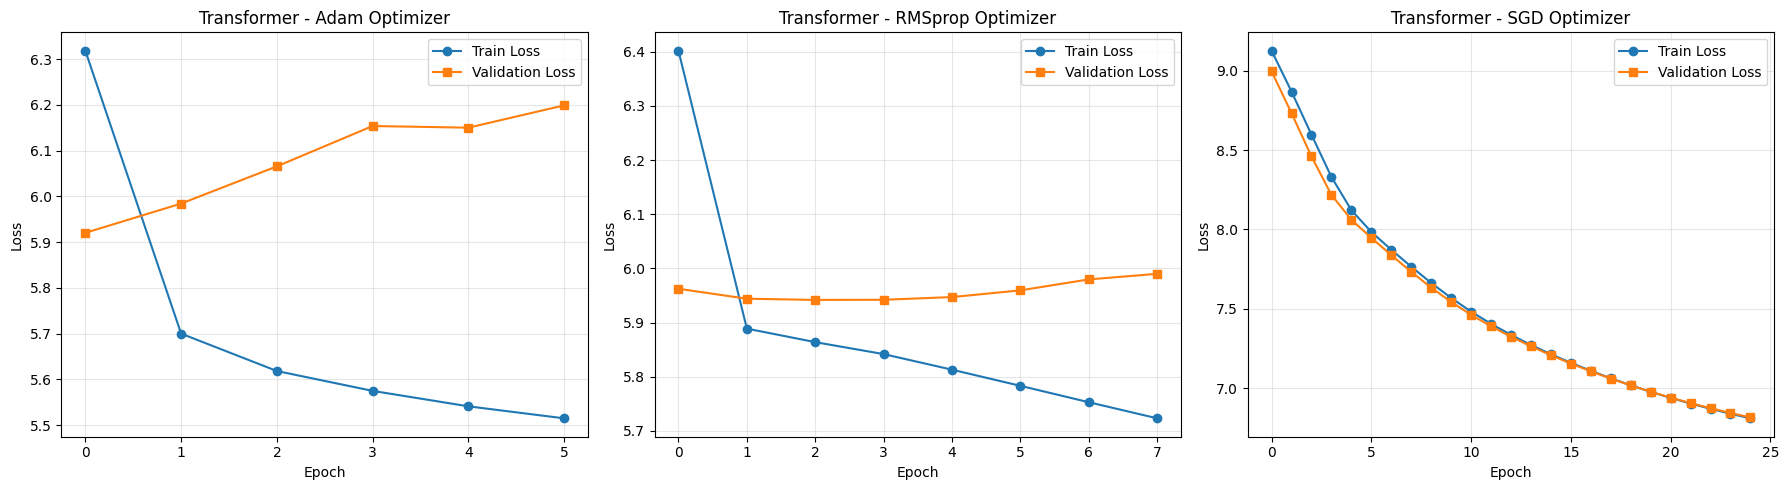

In [12]:
# Plot loss curves for all optimizers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

optimizers = ['Adam', 'RMSprop', 'SGD']
results_list = [adam_results, rmsprop_results, sgd_results]

for idx, (opt_name, result) in enumerate(zip(optimizers, results_list)):
    history = result['history']
    ax = axes[idx]

    ax.plot(history.history['loss'], label='Train Loss', marker='o')
    ax.plot(history.history['val_loss'], label='Validation Loss', marker='s')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'Transformer - {opt_name} Optimizer')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Final Evaluation Metrics


In [13]:
# Display metrics table
metrics_df = pd.DataFrame({
    'Optimizer': ['Adam', 'RMSprop', 'SGD'],
    'Train Loss': [adam_results['train_loss'], rmsprop_results['train_loss'], sgd_results['train_loss']],
    'Val Loss': [adam_results['val_loss'], rmsprop_results['val_loss'], sgd_results['val_loss']],
    'Test Loss': [adam_results['test_loss'], rmsprop_results['test_loss'], sgd_results['test_loss']],
    'Perplexity': [adam_results['perplexity'], rmsprop_results['perplexity'], sgd_results['perplexity']],
    'Training Time (s)': [adam_results['training_time'], rmsprop_results['training_time'], sgd_results['training_time']]
})

print("=" * 80)
print("Transformer Model - Final Evaluation Metrics")
print("=" * 80)
print(metrics_df.to_string(index=False))
print("=" * 80)


Transformer Model - Final Evaluation Metrics
Optimizer  Train Loss  Val Loss  Test Loss  Perplexity  Training Time (s)
     Adam    5.684427  5.920477   5.870478  354.418237          32.298912
  RMSprop    5.813680  5.941723   5.894597  363.070335          45.177027
      SGD    6.783206  6.817018   6.761827  864.220089          81.509157
